# Implementing a simple LLM Workflow using langchain and langgraph

In [6]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from typing import TypedDict
from dotenv import load_dotenv
from IPython.display import Image

In [2]:
# Loading the .env
load_dotenv()

True

In [3]:
# Defining Model of Groq:
model = ChatGroq(model="llama-3.3-70b-versatile", temperature=0.7)


In [4]:
# Graph State:
class llmState(TypedDict):
    question: str
    answer: str

In [12]:
def LLM_Question(state: llmState) -> llmState:
    # extract the question 
    response = state['question']

    # Prompting the model
    prompt = f"Answer the following question: {response}. Make sure you provide additional information to support your answer."

    # Invoking the LLM
    answer = model.invoke(prompt).content

    # Updating the state of Answer
    state['answer'] = answer

    return state

In [13]:
# Graph Creation:
graph = StateGraph(llmState)

# Nodes Creation:
graph.add_node("Question", LLM_Question)

# Edges Creation:
graph.add_edge(START, "Question")
graph.add_edge("Question", END)

# Workflow Compilation:
workflow = graph.compile()


In [14]:
# Executing Graph:
output = workflow.invoke({"question":"What is the capital of France?"})
print(output)

{'question': 'What is the capital of France?', 'answer': 'The capital of France is Paris. Located in the northern part of the country, Paris is the most populous city in France, with a population of over 2.1 million people within the city limits and over 12 million people in the metropolitan area. It is known as the "City of Light" (La Ville-Lumière) due to its historical role as a center of education, art, and culture.\n\nParis has been the capital of France since 987, when Hugh Capet, the Count of Paris, became the King of the Franks. Over the centuries, the city has played a significant role in French history, politics, and culture. It is home to many famous landmarks, such as the Eiffel Tower, Notre-Dame Cathedral, the Louvre Museum, and the Arc de Triomphe.\n\nAs the capital, Paris is the seat of the French government, with the President of France residing in the Élysée Palace. The city is also a major economic center, with a strong focus on finance, fashion, and tourism. The Pari

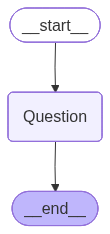

In [16]:
# Visualizing the Graph Image
Image(workflow.get_graph().draw_mermaid_png())